In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
# Load a sample dataset from seaborn suitable for classification algorithms
data = sns.load_dataset('titanic')
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [43]:
# Prepare X and Y for modeling
Y = data['survived']
X = data.drop('survived', axis=1)

# Handle missing values (simple strategy: drop rows with missing values)
X = X.dropna()
Y = Y.loc[X.index]

# Convert categorical columns to numeric using one-hot encoding
X_numeric = pd.get_dummies(X, columns=['sex', 'embarked'], drop_first=True)
print(X_numeric.head())

    pclass   age  sibsp  parch     fare  class    who  adult_male deck  \
1        1  38.0      1      0  71.2833  First  woman       False    C   
3        1  35.0      1      0  53.1000  First  woman       False    C   
6        1  54.0      0      0  51.8625  First    man        True    E   
10       3   4.0      1      1  16.7000  Third  child       False    G   
11       1  58.0      0      0  26.5500  First  woman       False    C   

    embark_town alive  alone  sex_male  embarked_Q  embarked_S  
1     Cherbourg   yes  False     False       False       False  
3   Southampton   yes  False     False       False        True  
6   Southampton    no   True      True       False        True  
10  Southampton   yes  False     False       False        True  
11  Southampton   yes   True     False       False        True  


In [44]:
# Convert all categorical columns in X to numeric using one-hot encoding
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_numeric = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(X_numeric.head())

    pclass   age  sibsp  parch     fare  adult_male  alone  sex_male  \
1        1  38.0      1      0  71.2833       False  False     False   
3        1  35.0      1      0  53.1000       False  False     False   
6        1  54.0      0      0  51.8625        True   True      True   
10       3   4.0      1      1  16.7000       False  False     False   
11       1  58.0      0      0  26.5500       False   True     False   

    embarked_Q  embarked_S  ...  who_woman  deck_B  deck_C  deck_D  deck_E  \
1        False       False  ...       True   False    True   False   False   
3        False        True  ...       True   False    True   False   False   
6        False        True  ...      False   False   False   False    True   
10       False        True  ...      False   False   False   False   False   
11       False        True  ...       True   False    True   False   False   

    deck_F  deck_G  embark_town_Queenstown  embark_town_Southampton  alive_yes  
1    False   Fals

In [45]:
print(Y.head())

1     1
3     1
6     0
10    1
11    1
Name: survived, dtype: int64


In [46]:
print(X.isna().sum())
print(Y.isna().sum())

pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64
0


In [47]:
# Perform logistic regression on the processed Titanic dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Use X_numeric and Y for modeling
X_train, X_test, Y_train, Y_test = train_test_split(X_numeric, Y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=400)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)
print('Logistic Regression Accuracy:', accuracy_score(Y_test, y_pred))

Logistic Regression Accuracy: 1.0


In [48]:
# Apply feature scaling (Standardization) to X_numeric
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LogisticRegression(max_iter=400)
model_scaled.fit(X_train_scaled, Y_train)
y_pred_scaled = model_scaled.predict(X_test_scaled)
print('Logistic Regression Accuracy with scaling:', accuracy_score(Y_test, y_pred_scaled))

Logistic Regression Accuracy with scaling: 1.0


Best K: 15, Best Accuracy: 0.918918918918919


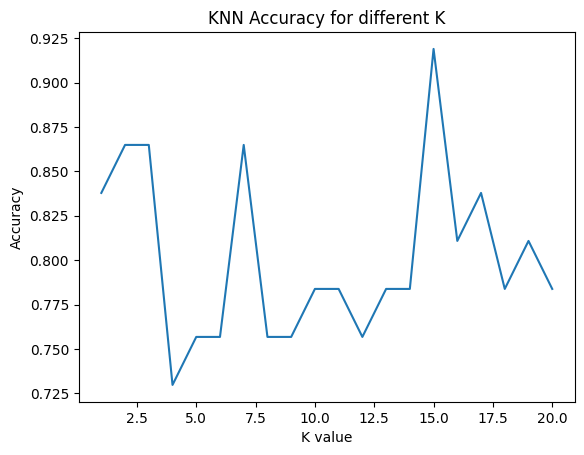

In [49]:
# Implement KNN on the processed Titanic dataset and select best k
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

best_k = 1
best_acc = 0
best_pred = None
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, Y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(Y_test, y_pred)
    if acc > best_acc:
        best_acc = acc
        best_k = k
        best_pred = y_pred

print(f'Best K: {best_k}, Best Accuracy: {best_acc}')
y_pred_knn = best_pred

plt.plot(range(1, 21), [accuracy_score(Y_test, KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, Y_train).predict(X_test_scaled)) for k in range(1, 21)])
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for different K')
plt.show()

In [50]:
# Implement Decision Tree on the processed Titanic dataset
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train_scaled, Y_train)
y_pred_dtree = dtree.predict(X_test_scaled)
print('Decision Tree Accuracy with scaling:', accuracy_score(Y_test, y_pred_dtree))

Decision Tree Accuracy with scaling: 1.0


In [51]:
# Implement Naive Bayes on the processed Titanic dataset
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_scaled, Y_train)
y_pred_nb = nb.predict(X_test_scaled)
print('Naive Bayes Accuracy with scaling:', accuracy_score(Y_test, y_pred_nb))

Naive Bayes Accuracy with scaling: 1.0


In [52]:
# Implement SVM on the processed Titanic dataset
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, Y_train)
y_pred_svm = svm.predict(X_test_scaled)
print('SVM Accuracy with scaling:', accuracy_score(Y_test, y_pred_svm))

SVM Accuracy with scaling: 0.972972972972973


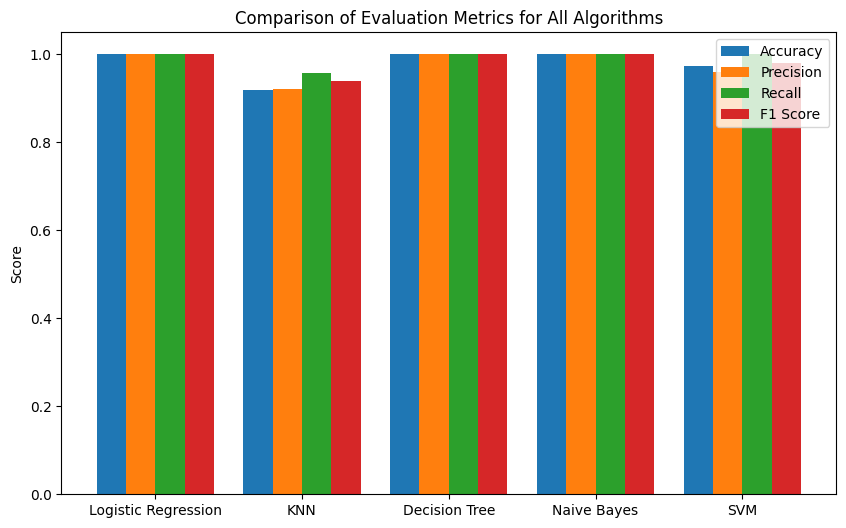

In [53]:
# Compare evaluation metrics for all algorithms used
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': y_pred_scaled,
    'KNN': y_pred_knn,
    'Decision Tree': y_pred_dtree,
    'Naive Bayes': y_pred_nb,
    'SVM': y_pred_svm
}

metrics = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': []}

for name, preds in models.items():
    metrics['Accuracy'].append(accuracy_score(Y_test, preds))
    metrics['Precision'].append(precision_score(Y_test, preds))
    metrics['Recall'].append(recall_score(Y_test, preds))
    metrics['F1 Score'].append(f1_score(Y_test, preds))

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - 1.5*width, metrics['Accuracy'], width, label='Accuracy')
rects2 = ax.bar(x - 0.5*width, metrics['Precision'], width, label='Precision')
rects3 = ax.bar(x + 0.5*width, metrics['Recall'], width, label='Recall')
rects4 = ax.bar(x + 1.5*width, metrics['F1 Score'], width, label='F1 Score')

ax.set_ylabel('Score')
ax.set_title('Comparison of Evaluation Metrics for All Algorithms')
ax.set_xticks(x)
ax.set_xticklabels(list(models.keys()))
ax.legend()

plt.show()